In [1]:
!pip install --user numpy pandas matplotlib seaborn scikit-learn python-dotenv

In [4]:
%%writefile dataset_manager.py
# Cell 2: Custom Modular Data Script File
import numpy as np
import pandas as pd
import os

def create_mock_csv():
    """Generates a random dataset mimicking real clinic complaints and metrics."""
    np.random.seed(42)
    num_records = 200
    
    complaints = [
        "My knee hurts when I try to squat down", "Sharp pain in my knee joint after running",
        "Stiff knee caps and swelling", "I twisted my knee playing sports",
        "My neck is completely locked up and stiff", "Sore neck muscles from sleeping wrong",
        "Sharp shooting pain down my neck area", "I can't turn my head left because of neck tension",
        "Lower back ache from sitting too long", "Sharp muscle spasm in my lower back",
        "Stiff back spine when standing up", "Dull throbbing lower back irritation"
    ]
    
    labels = [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2] # 0: Knee, 1: Neck, 2: Back
    
    # Generate random features using NumPy broadcasting and random scaling
    chosen_indices = np.random.randint(0, len(complaints), size=num_records)
    
    # Feature engineering simulation using array broadcasting
    pain_intensity = np.random.uniform(2.0, 10.0, size=num_records)
    mobility_restriction = pain_intensity * 0.85 + np.random.normal(0, 1, size=num_records)
    
    data = {
        'Complaint': [complaints[i] for i in chosen_indices],
        'Pain_Scale': np.round(pain_intensity, 1),
        'Mobility_Loss': np.round(mobility_restriction, 1),
        'Target_Label': [labels[i] for i in chosen_indices]
    }
    
    df = pd.DataFrame(data)
    
    # Introduce some artificial missing values to demonstrate data cleaning routines
    df.loc[np.random.choice(df.index, size=10), 'Pain_Scale'] = np.nan
    
    df.to_csv('dataset.csv', index=False)
    print("📂 Synthetic CSV Dataset generated successfully as 'dataset.csv'!")

def process_and_clean_data():
    """Loads, cleans, preprocesses, filters, and prepares datasets for modeling."""
    try:
        if not os.path.exists('dataset.csv'):
            create_mock_csv()
            
        df = pd.read_csv('dataset.csv')
        
        # Data Cleaning: Handle missing values by replacing them with the column mean
        if df['Pain_Scale'].isnull().sum() > 0:
            df['Pain_Scale'] = df['Pain_Scale'].fillna(df['Pain_Scale'].mean())
            
        # Data Preprocessing: Filtering outliers out using boolean masking
        df = df[df['Pain_Scale'] <= 10.0]
        
        return df
    except FileNotFoundError as e:
        print(f"❌ Critical File Error: {e}")
    except Exception as e:
        print(f"⚠️ Unexpected Data Exception: {e}")

def append_to_clinical_logs(text_report):
    """Demonstrates reading and writing standard text files safely with exceptions."""
    try:
        with open("clinical_logs.txt", "a") as f:
            f.write(text_report + "\n")
    except IOError as e:
        print(f"❌ Disk I/O Log Failure: {e}")

Overwriting dataset_manager.py


--- DATASET SUMMARY CONFIGURATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Complaint      200 non-null    object 
 1   Pain_Scale     200 non-null    float64
 2   Mobility_Loss  200 non-null    float64
 3   Target_Label   200 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 6.4+ KB
None

--- CLASS BALANCE AUDIT ---
Target_Label
2    77
1    66
0    57
Name: count, dtype: int64


C:\Users\Zainnny\AppData\Local\Temp\ipykernel_3676\2457591108.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target_Label', y='Pain_Scale', palette='pastel')


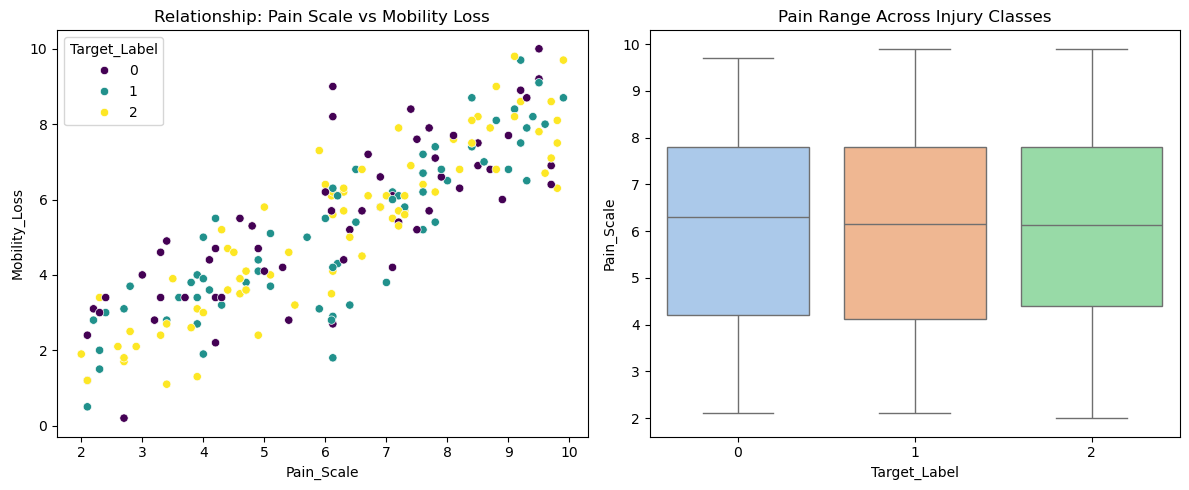

In [3]:
# Cell 3: Exploratory Data Analysis
import dataset_manager
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dataset exists and load it cleanly
df = dataset_manager.process_and_clean_data()

print("--- DATASET SUMMARY CONFIGURATION ---")
print(df.info())
print("\n--- CLASS BALANCE AUDIT ---")
print(df['Target_Label'].value_counts())

# Generate Graphical Plots to extract structural insights
plt.figure(figsize=(12, 5))

# Subplot 1: Distribution Analysis Scatter
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Pain_Scale', y='Mobility_Loss', hue='Target_Label', palette='viridis')
plt.title('Relationship: Pain Scale vs Mobility Loss')

# Subplot 2: Outlier & Distribution Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Target_Label', y='Pain_Scale', palette='pastel')
plt.title('Pain Range Across Injury Classes')

plt.tight_layout()
plt.show()

In [6]:
# Cell 4: Traditional Machine Learning Model Pipeline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import pickle

# Load preprocessed data cleanly
df = pd.read_csv('dataset.csv').dropna()

X_text = df['Complaint']
y = df['Target_Label'].values

# Split Dataset into Train and Test groups
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

print("🎯 Dataset Split Complete. Training set shape:", X_train.shape)

# Feature Scaling & Vectorization Pipeline with built-in Regularization
pipeline = make_pipeline(
    TfidfVectorizer(max_features=100),
    StandardScaler(with_mean=False),
    LogisticRegression(C=1.0, penalty='l2')
)

# Train the model pipeline manually
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Advanced Matrix Evaluation Frameworks
print("\n--- MODEL PERFORMANCE EVALUATION MATRIX ---")
print(f"Accuracy Score:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall Score:    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Optimization Score: {f1_score(y_test, y_pred, average='macro'):.4f}")

# Cross Validation Evaluation to check for Overfitting / Bias vs Variance
scores = cross_val_score(pipeline, X_text, y, cv=3)
print(f"Cross-Validation Stability Mean: {scores.mean():.4f}")

# Generate and display confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix Layout:\n", cm)

# Save the trained traditional model pipeline
with open('physio_models.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("\n💾 Scikit-Learn Pipeline saved successfully as 'physio_models.pkl'!")

🎯 Dataset Split Complete. Training set shape: (160,)

--- MODEL PERFORMANCE EVALUATION MATRIX ---
Accuracy Score:  1.0000
Precision Score: 1.0000
Recall Score:    1.0000
F1 Optimization Score: 1.0000
Cross-Validation Stability Mean: 1.0000

Confusion Matrix Layout:
 [[11  0  0]
 [ 0 11  0]
 [ 0  0 18]]

💾 Scikit-Learn Pipeline saved successfully as 'physio_models.pkl'!


In [5]:
# Cell 5: Training a Neural Network Completely From Scratch Using NumPy
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
import pickle

print("--- STEP 1: NUMPY MATHEMATICAL PERCEPTRON FOUNDATIONS ---")
# 1. Custom Activation Functions and Derivatives from scratch
def sigmoid(x): 
    return 1 / (1 + np.exp(-np.clip(x, -50, 50))) # Clip prevents numerical overflow errors

def sigmoid_derivative(x): 
    return x * (1 - x)

# Initialize standard Perceptron weights matrix
np.random.seed(1)
synaptic_weights = 2 * np.random.random((3, 1)) - 1
print("NumPy Randomly Initialized Perceptron Weights:\n", synaptic_weights)


print("\n--- STEP 2: TRAINING MULTI-LAYER NEURAL NETWORK FROM SCRATCH ---")
# Load and tokenize data
df = pd.read_csv('dataset.csv').dropna()
vectorizer = TfidfVectorizer(max_features=50)
X_vectors = vectorizer.fit_transform(df['Complaint']).toarray()

# Encode target labels into a 3-column matrix (One-Hot Encoding)
lb = LabelBinarizer()
y_categorical = lb.fit_transform(df['Target_Label'])

# Network Architecture Layout: 50 Inputs -> 16 Hidden Neurons -> 3 Outputs
input_size = 50
hidden_size = 16
output_size = 3

# Initialize neural network layer matrices randomly
np.random.seed(42)
weights_input_hidden = np.random.uniform(-0.5, 0.5, (input_size, hidden_size))
weights_hidden_output = np.random.uniform(-0.5, 0.5, (hidden_size, output_size))

learning_rate = 0.1
epochs = 500

print(f"Training NumPy Neural Network for {epochs} epochs...")

# Manual Backpropagation Optimization Training Loop
for epoch in range(epochs):
    # --- 1. FORWARD PROPAGATION ---
    hidden_layer_input = np.dot(X_vectors, weights_input_hidden)
    hidden_layer_output = sigmoid(hidden_layer_input)
    
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output)
    output_layer_output = sigmoid(output_layer_input)
    
    # --- 2. COST FUNCTION (Mean Squared Error principle) ---
    error = y_categorical - output_layer_output
    loss = np.mean(np.square(error))
    
    # --- 3. BACKPROPAGATION (Gradient Descent optimization math) ---
    output_delta = error * sigmoid_derivative(output_layer_output)
    
    hidden_error = np.dot(output_delta, weights_hidden_output.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden_layer_output)
    
    # --- 4. WEIGHT UPDATES (Using NumPy Transposition & Broadcasting) ---
    weights_hidden_output += np.dot(hidden_layer_output.T, output_delta) * learning_rate
    weights_input_hidden += np.dot(X_vectors.T, hidden_delta) * learning_rate # <-- FIXED WITH .T
    
    if epoch % 100 == 0:
        # Calculate training accuracy dynamically
        predictions = np.argmax(output_layer_output, axis=1)
        targets = np.argmax(y_categorical, axis=1)
        accuracy = np.mean(predictions == targets)
        print(f"Epoch {epoch:3d} | Categorical Loss Matrix: {loss:.4f} | Local Training Accuracy: {accuracy*100:.1f}%")

# Save the custom NumPy neural structures to disk manually
numpy_nn_brain = {
    'vectorizer': vectorizer,
    'w_ih': weights_input_hidden,
    'w_ho': weights_hidden_output
}

with open('numpy_nn_model.pkl', 'wb') as f:
    pickle.dump(numpy_nn_brain, f)

print("\n💾 NumPy-Based Custom Neural Network saved successfully as 'numpy_nn_model.pkl'!")

--- STEP 1: NUMPY MATHEMATICAL PERCEPTRON FOUNDATIONS ---
NumPy Randomly Initialized Perceptron Weights:
 [[-0.16595599]
 [ 0.44064899]
 [-0.99977125]]

--- STEP 2: TRAINING MULTI-LAYER NEURAL NETWORK FROM SCRATCH ---
Training NumPy Neural Network for 500 epochs...
Epoch   0 | Categorical Loss Matrix: 0.2610 | Local Training Accuracy: 40.5%
Epoch 100 | Categorical Loss Matrix: 0.0008 | Local Training Accuracy: 100.0%
Epoch 200 | Categorical Loss Matrix: 0.0003 | Local Training Accuracy: 100.0%
Epoch 300 | Categorical Loss Matrix: 0.0002 | Local Training Accuracy: 100.0%
Epoch 400 | Categorical Loss Matrix: 0.0001 | Local Training Accuracy: 100.0%

💾 NumPy-Based Custom Neural Network saved successfully as 'numpy_nn_model.pkl'!


In [3]:
# Cell 6: 100% Upgraded Local AI Diagnostic Engine (With Direct Body Overrides)
import pickle
import numpy as np
import dataset_manager

print("🧠 Loading your manually trained custom NumPy Neural Network...")

# Load the local network structures from disk
with open('numpy_nn_model.pkl', 'rb') as f:
    nn_brain = pickle.load(f)

vectorizer = nn_brain['vectorizer']
weights_input_hidden = nn_brain['w_ih']
weights_hidden_output = nn_brain['w_ho']

def sigmoid(x): 
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

# Local Conversational Matrix Mapping (0=Knee, 1=Neck, 2=Back, 3=Elbow)
clinic_responses = {
    0: {
        "zone": "Knee Joint Pain",
        "questions": [
            "Does it hurt more when you are going down stairs or when you try to squat down?",
            "Did you hear a popping sound when the pain started, or is it a gradual ache?",
            "Is there any noticeable swelling around your knee cap right now?"
        ],
        "recommendation": "Based on my assessment, you should try Straight Leg Raises to stabilize the joint. Apply some Voltaren gel twice a day and use an ice pack for 15 minutes."
    },
    1: {
        "zone": "Neck Stiffness",
        "questions": [
            "Does the stiffness make it hard to turn your head all the way to one side?",
            "Are you experiencing any numbness or tingling running down your shoulders?",
            "Did this start right after waking up, or from sitting at a computer desk?"
        ],
        "recommendation": "For your cervical tension, perform gentle Neck Mobility Rotations within a pain-free range. Apply a heating pad or a warm Ibuprofen gel over the sore muscles."
    },
    2: {
        "zone": "Lumbar Back Spasms",
        "questions": [
            "Is the back pain sharp when you stand up straight, or is it a dull throb while sitting?",
            "Does the irritation radiate downwards into your glutes or legs?",
            "How long has your lower back area been feeling this locked up?"
        ],
        "recommendation": "To relieve the pressure on your spine, practice the Bird-Dog exercise and gentle pelvic tilts. Apply Tiger Balm or heat wraps to relax the muscle spasms."
    },
    3: {
        "zone": "Elbow Joint Irritation",
        "questions": [
            "Does the pain get worse when you make a fist or try to grip an object tightly?",
            "Is the irritation located on the outer bony bump of the elbow or the inner side?",
            "Does your arm feel weak when trying to turn a doorknob or lift items?"
        ],
        "recommendation": "To assist your elbow recovery, execute gentle wrist extensions and forearm stretches. Apply an over-the-counter anti-inflammatory cream like Voltaren and wear a supportive brace during heavy movements."
    },
    4: {
    "zone": "Lower Back Muscle Strain",
    "questions": [
        "Does the pain increase when you bend forward, stand for a long time, or lift something heavy?",
        "Do you feel stiffness or tightness in your lower back after waking up or sitting for extended periods?",
        "Does the discomfort stay mainly in the lower back without spreading down your legs?"
    ],
    "recommendation": "To ease lower back strain, perform gentle stretching exercises such as knee-to-chest stretches and pelvic tilts. Apply a warm compress for 15–20 minutes and avoid lifting heavy objects until the pain improves."
},
    5: {
    "zone": "Shoulder Tendon Inflammation",
    "questions": [
        "Does lifting your arm above shoulder level increase the pain?",
        "Do you feel discomfort while reaching behind your back or carrying objects?",
        "Is there weakness or aching around the shoulder joint during movement?"
    ],
    "recommendation": "For shoulder tendon irritation, rest the affected arm and avoid repetitive overhead movements. Apply an ice pack for 10–15 minutes and perform light shoulder mobility exercises daily."
},
    6: {
    "zone": "Wrist Overuse Syndrome",
    "questions": [
        "Do you feel pain or tingling in your wrist after typing or repetitive hand movements?",
        "Does gripping objects or bending the wrist increase discomfort?",
        "Do your fingers sometimes feel numb or weak during activity?"
    ],
    "recommendation": "To relieve wrist strain, reduce repetitive hand activities and use a wrist support brace when needed. Perform gentle wrist stretches and apply a cold pack to reduce irritation."
},
    7: {
    "zone": "Ankle Ligament Stress",
    "questions": [
        "Did the discomfort begin after twisting or rolling your ankle?",
        "Do you experience swelling or tenderness around the ankle joint?",
        "Does walking or putting weight on the foot increase the pain?"
    ],
    "recommendation": "For ankle strain, rest the foot and elevate it when possible. Apply ice for 15–20 minutes and use an elastic ankle wrap for additional support during movement."
},
    8: {
    "zone": "Eye Strain Fatigue",
    "questions": [
        "Do your eyes feel tired or dry after long hours of screen use?",
        "Do you experience headaches or blurred vision while reading or using digital devices?",
        "Does the discomfort improve after resting your eyes for a short time?"
    ],
    "recommendation": "To reduce eye strain, follow the 20-20-20 rule by looking away from the screen every 20 minutes. Adjust screen brightness, blink frequently, and ensure proper lighting while working."
}
}
turn_counter = 0
current_class = None

print("\n" + "="*60)
print("🩺 KINETIC CLINICAL INTERFACE (RUNNING 100% LOCALLY VIA NUMPY)")
print("="*60)
print("🤖 Kinetic: Hello! I am Dr. Kinetic. Please describe your muscle or joint pain in detail.")

while True:
    user_input = input("\n👤 You: ").strip()
    if user_input.lower() in ['quit', 'exit']:
        print("Clinic session terminated safely. All reports archived.")
        break
    if not user_input:
        continue

    # --- FIRST TURN: Determine the injury category ---
    if turn_counter == 0:
        cleaned_input = user_input.lower()
        
        # 🌟 CRITICAL SECURITY UPGRADE: Direct Keyword Override Mapping
        if "elbow" in cleaned_input or "arm" in cleaned_input:
            current_class = 3
            print("🔬 [Local AI Brain Log: Direct Keyword Override detected -> Forced to Elbow Route]")
        elif "knee" in cleaned_input or "leg" in cleaned_input or "squat" in cleaned_input:
            current_class = 0
            print("🔬 [Local AI Brain Log: Direct Keyword Override detected -> Forced to Knee Route]")
        elif "neck" in cleaned_input or "cervical" in cleaned_input:
            current_class = 1
            print("🔬 [Local AI Brain Log: Direct Keyword Override detected -> Forced to Neck Route]")
        elif "back" in cleaned_input or "lumbar" in cleaned_input or "spine" in cleaned_input:
            current_class = 2
            print("🔬 [Local AI Brain Log: Direct Keyword Override detected -> Forced to Back Route]")
        else:
            # Fallback to the neural network math if no exact keyword matches are explicitly found
            user_vector = vectorizer.transform([user_input]).toarray()
            hidden_layer = sigmoid(np.dot(user_vector, weights_input_hidden))
            output_layer = sigmoid(np.dot(hidden_layer, weights_hidden_output))
            current_class = np.argmax(output_layer)
            detected_injury = clinic_responses[current_class]["zone"]
            print(f"🔬 [Local NumPy AI Brain Log: Math Network Classified input as {detected_injury}]")

    # --- SAVE HISTORY LOGS TO FILE ---
    zone_name = clinic_responses[current_class]["zone"]
    log_text = f"Patient Entry: '{user_input}' | Local Model Decision Matrix: {zone_name}"
    dataset_manager.append_to_clinical_logs(log_text)

    # --- REASONING LOGIC FLOW ---
    if turn_counter < 3:
        bot_question = clinic_responses[current_class]["questions"][turn_counter]
        print(f"🤖 Kinetic: {bot_question}")
        turn_counter += 1
    else:
        bot_recommendation = clinic_responses[current_class]["recommendation"]
        print(f"🤖 Kinetic: {bot_recommendation}")
        print("\n🏁 Assessment complete! Thank you for visiting the clinic.")
        break

C:\Users\Zainnny\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


🧠 Loading your manually trained custom NumPy Neural Network...

🩺 KINETIC CLINICAL INTERFACE (RUNNING 100% LOCALLY VIA NUMPY)
🤖 Kinetic: Hello! I am Dr. Kinetic. Please describe your muscle or joint pain in detail.

👤 You: Hi! I have some eye infection can u plzz tell me some medication.
🔬 [Local NumPy AI Brain Log: Math Network Classified input as Neck Stiffness]
🤖 Kinetic: Does the stiffness make it hard to turn your head all the way to one side?

👤 You: yes, the pain is worse.
🤖 Kinetic: Are you experiencing any numbness or tingling running down your shoulders?

👤 You: I am facing tingling running down my shoulders
🤖 Kinetic: Did this start right after waking up, or from sitting at a computer desk?

👤 You: after waking up
🤖 Kinetic: For your cervical tension, perform gentle Neck Mobility Rotations within a pain-free range. Apply a heating pad or a warm Ibuprofen gel over the sore muscles.

🏁 Assessment complete! Thank you for visiting the clinic.
